# 🏆 Bengali LLM Hallucination Detection — Full Research Pipeline (V2)

Predicts whether a Bangla LLM response (`response_bn`) to a prompt (`prompt_bn`), optionally
grounded in a `context`, is **faithful (`label = 1`)** or **hallucinated (`label = 0`)**.

This notebook implements the full plan: multi-signal feature engineering (lexical, semantic,
logical/NLI, factual, cross-lingual, entity/numeric consistency, cultural-default detection),
feature fusion, multi-model training (LR / RF / XGBoost / LightGBM), ensembling
(soft voting / weighted average / stacking), stratified CV, error analysis, threshold
optimization, and a Kaggle-ready `submission.csv`.

**Contents**
1. Environment Setup
2. Load Dataset
3. Exploratory Data Analysis
4. Text Preprocessing
5. Feature Engineering (13 feature blocks)
6. Feature Fusion
7. Model Training
8. Ensemble Learning
9. Cross Validation Summary
10. Error Analysis
11. Threshold Optimization
12. Test Inference & Submission
13. Next Steps


# Part 1 — Environment Setup

In [1]:
# Install required packages (safe to re-run; quiet)
!pip install -q -U scikit-learn xgboost lightgbm sentence-transformers transformers accelerate bitsandbytes sentencepiece tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklear

In [2]:
import os
import re
import json
import warnings
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_predict, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Torch device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Torch device: cuda
GPU: Tesla T4


In [3]:
# ---- Configuration ----
DATA_DIR = "/kaggle/input/competitions/bengali-hallucination"
TRAIN_PATH = f"{DATA_DIR}/dataset samples.json"   # labeled sample split
TEST_PATH = f"{DATA_DIR}/test set.csv"                # unlabeled test split

# Model names (all open-weight, for offline / Phase-2 compatibility)
EMBED_MODEL = "intfloat/multilingual-e5-base"                                  # Feature 2/3/13
NLI_MODEL = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"        # Feature 4
FACTCHECK_MODEL = "Qwen/Qwen2.5-7B-Instruct"                                    # Feature 5
TRANSLATE_MODEL = "facebook/nllb-200-distilled-600M"                           # Feature 6
NER_MODEL = "Davlan/xlm-roberta-base-ner-hrl"                                   # Feature 7

CV_FOLDS = 5
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("Configuration set.")


Configuration set.


# Part 2 — Load Dataset

In [4]:
with open(TRAIN_PATH, encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame(records)
print(f"{len(df)} rows, columns: {list(df.columns)}")
df.head()


299 rows, columns: ['context', 'prompt_bn', 'response_bn', 'label']


,context,prompt_bn,response_bn,label
0,উইন্ডোজে ইউনিকোড ভিত্তিক বাংলা লেখার জন্য ২০০৩...,অভ্র কিবোর্ড কে উদ্ভাবন করেন ?,মেহদী হাসান খান,1
1,[NULL],"""ধান্ধা"" এর ভাবার্থ কী?",কোন অসৎ উদ্দেশ্য,1
2,[NULL],‘কাঁঠালপাড়া’য় জন্মগ্রহণ করেন কোন লেখক?,শরৎচন্দ্র চট্টোপাধ্যায়,0
3,তারেক মাসুদ পরিচালিত প্রথম স্বল্পদৈর্ঘ্য চলচ্চ...,তারেক মাসুদ পরিচালিত সর্বশেষ বাংলা চলচ্চিত্রটি...,রানওয়ে,0
4,[NULL],৩০ থেকে ৪০ পর্যন্ত সংখ্যা থেকে যে কোন একটিকে ই...,৬/১১,0


In [5]:
# ---- Missing values ----
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
context        2
prompt_bn      0
response_bn    0
label          0
dtype: int64


In [6]:
# ---- Normalize dtypes / handle NULL context ----
for col in ["prompt_bn", "response_bn"]:
    df[col] = df[col].astype(str)

NO_CONTEXT_VALUES = {"", "nan", "NaN", "[NULL]", "None", None}

def clean_context(value):
    if pd.isna(value) or str(value).strip() in NO_CONTEXT_VALUES:
        return ""
    return str(value).strip()

df["context"] = df["context"].apply(clean_context)
df["has_context"] = df["context"].str.len() > 0
df["has_context_int"] = df["has_context"].astype(int)

print(f"Rows with context   : {df['has_context'].sum()}")
print(f"Rows without context: {(~df['has_context']).sum()}")


Rows with context   : 130
Rows without context: 169


In [7]:
# ---- Label distribution ----
print("Label balance (1 = faithful, 0 = hallucinated):")
print(df["label"].value_counts(normalize=True).rename("share").to_frame())

print("\nLabel balance split by context availability:")
print(df.groupby("has_context")["label"].value_counts(normalize=True).unstack())


Label balance (1 = faithful, 0 = hallucinated):
          share
label          
1      0.545151
0      0.454849

Label balance split by context availability:
label               0         1
has_context                    
False        0.526627  0.473373
True         0.361538  0.638462


In [8]:
# ---- Load test set (may not exist yet locally) ----
try:
    test_df = pd.read_csv(TEST_PATH)
    print(f"Test set: {len(test_df)} rows, columns: {list(test_df.columns)}")
except FileNotFoundError:
    test_df = None
    print(f'No test file found at "{TEST_PATH}" yet — test inference cells will be skipped until it exists.')


Test set: 2516 rows, columns: ['id', 'context', 'prompt_bn', 'response_bn']


# Part 3 — Exploratory Data Analysis

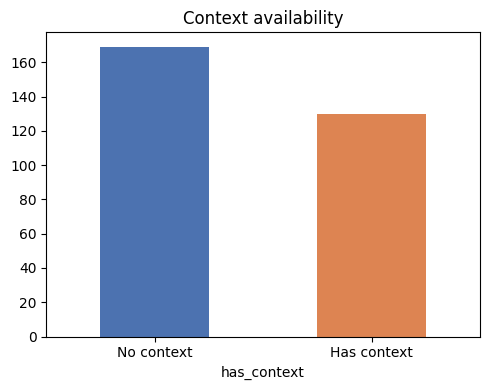

In [9]:
# ---- Context vs no-context distribution ----
fig, ax = plt.subplots(figsize=(5, 4))
df["has_context"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No context", "Has context"], rotation=0)
ax.set_title("Context availability")
plt.tight_layout()
plt.show()


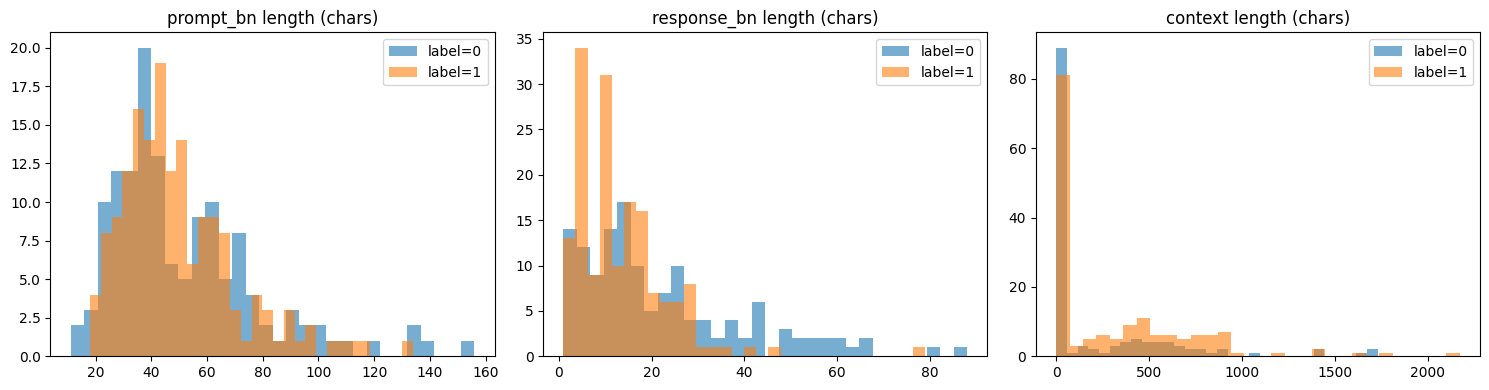

,prompt_bn_len,response_bn_len,context_len,prompt_bn_wordcount,response_bn_wordcount,context_wordcount
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,50.558528,17.177258,264.508361,8.331104,2.816054,38.277592
std,23.752056,14.897818,392.751073,4.001770,2.284235,56.725524
min,11.000000,1.000000,0.000000,2.000000,1.000000,0.000000
25%,34.500000,7.000000,0.000000,6.000000,1.000000,0.000000
50%,45.000000,14.000000,0.000000,7.000000,2.000000,0.000000
75%,62.000000,22.000000,478.000000,10.000000,3.000000,67.500000
max,156.000000,88.000000,2174.000000,29.000000,13.000000,334.000000


In [10]:
# ---- Prompt / response / context length distributions ----
text_cols = ["prompt_bn", "response_bn", "context"]
for col in text_cols:
    df[f"{col}_len"] = df[col].str.len()
    df[f"{col}_wordcount"] = df[col].str.split().str.len()

fig, axes = plt.subplots(1, len(text_cols), figsize=(15, 4))
for ax, col in zip(axes, text_cols):
    for label, subset in df.groupby("label"):
        ax.hist(subset[f"{col}_len"], bins=30, alpha=0.6, label=f"label={label}")
    ax.set_title(f"{col} length (chars)")
    ax.legend()
plt.tight_layout()
plt.show()

df[[f"{c}_len" for c in text_cols] + [f"{c}_wordcount" for c in text_cols]].describe()


In [11]:
# ---- Vocabulary statistics ----
def bengali_tokens(text):
    return re.findall(r"[\u0980-\u09FF]+", text)

all_response_tokens = [tok for text in df["response_bn"] for tok in bengali_tokens(text)]
vocab = Counter(all_response_tokens)
print(f"Total response tokens : {len(all_response_tokens)}")
print(f"Unique vocabulary     : {len(vocab)}")
print("\nTop 15 most common tokens:")
for tok, cnt in vocab.most_common(15):
    print(f"  {tok:<20} {cnt}")


Total response tokens : 818
Unique vocabulary     : 652

Top 15 most common tokens:
  সালে                 10
  সালের                8
  ও                    7
  বা                   6
  ৬                    5
  প্রায়               5
  কিলোমিটার            5
  থেকে                 5
  এর                   4
  প্রথম                4
  ১৫                   4
  করা                  4
  নাম                  4
  ছিল                  4
  হাসান                3


In [12]:
# ---- Class imbalance summary ----
imbalance_ratio = df["label"].value_counts(normalize=True)
print("Class imbalance ratio:")
print(imbalance_ratio)
print(f"\nImbalance factor (majority/minority): {imbalance_ratio.max() / imbalance_ratio.min():.2f}x")


Class imbalance ratio:
label
1    0.545151
0    0.454849
Name: proportion, dtype: float64

Imbalance factor (majority/minority): 1.20x


In [13]:
# ---- Example inspection ----
pd.set_option("display.max_colwidth", 120)
for label_val in sorted(df["label"].unique()):
    print(f"\n{'='*60}\nExamples with label={label_val}\n{'='*60}")
    display(df[df["label"] == label_val][["prompt_bn", "response_bn", "context", "label"]].sample(
        min(2, (df["label"] == label_val).sum()), random_state=RANDOM_STATE))



Examples with label=0


,prompt_bn,response_bn,context,label
146,শিব রাত্রির সলতে – বাগধারটির অর্থ কী?,শিবরাত্রির গুরুত্ব,,0
79,সৌরভ গাঙ্গুলি কত সালে ভারতীয় জাতীয় দলের হয়ে প্রথম টেস্ট ম্যাচ খেলেন ?,১৯৯৫ সালে।,তিনি প্রথম জীবনে স্কুল ও রাজ্যের হয়ে ক্রিকেট খেলা শুরু করেন ক্রিকেট জীবনের বিভিন্ন ক্ষেত্রে সাফল্য পেতে থাকেন তিনি।...,0



Examples with label=1


,prompt_bn,response_bn,context,label
258,বাংলাদেশ জাতীয় সংসদের প্রথম নির্বাচন কবে অনুষ্ঠিত হয়?,৭ মার্চ ১৯৭৩ খৃঃ,,1
215,অপারেশন জ্যাকপটের সূচনা হয় কোন শহর থেকে ?,১৯৭১-এর ১৫ আগস্ট রাত ১২টার পর,অপারেশন জ্যাকপট বাংলাদেশের স্বাধীনতা যুদ্ধের সময় নৌ-সেক্টর পরিচালিত সফলতম গেরিলা অপারেশন। এটি ছিল একটি আত্মঘাতী অপা...,1


# Part 4 — Text Preprocessing

In [14]:
# ---- Unicode normalization + Bengali cleaning ----
ZERO_WIDTH = "\u200b\u200c\u200d\ufeff"

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize("NFC", text)          # canonical Bengali conjunct forms
    text = "".join(ch for ch in text if ch not in ZERO_WIDTH)
    text = re.sub(r"\s+", " ", text).strip()            # collapse whitespace
    return text

for col in ["prompt_bn", "response_bn", "context"]:
    df[f"{col}_clean"] = df[col].apply(normalize_text)

print("Preprocessing applied. Example:")
print(repr(df["response_bn"].iloc[0][:80]), "->")
print(repr(df["response_bn_clean"].iloc[0][:80]))


Preprocessing applied. Example:
'মেহদী হাসান খান' ->
'মেহদী হাসান খান'


# Feature Engineering

Each block below builds one independent, complementary signal. All features are merged
in **Feature Fusion**. Every block is safe to skip/re-run independently — heavy models
are loaded once and cached in module-level variables.

## Feature 1 — TF-IDF

Purpose: capture lexical patterns. Kept deliberately small (character n-grams, low
`max_features`) so it acts as a **supporting** signal rather than dominating the model
the way it did in the starter baseline (~0.52 Macro-F1).

In [15]:
def select_column(name):
    return FunctionTransformer(lambda frame: frame[name].to_numpy(), validate=False)

def tfidf_branch(name, max_features=500):
    return Pipeline([
        ("select", select_column(name)),
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), max_features=max_features)),
    ])

TFIDF_TEXT_COLS = ["prompt_bn_clean", "response_bn_clean"]
print("TF-IDF branches defined for:", TFIDF_TEXT_COLS)


TF-IDF branches defined for: ['prompt_bn_clean', 'response_bn_clean']


## Feature 2 — Sentence Embeddings

Purpose: capture semantic meaning beyond exact wording, using a multilingual sentence
encoder (`multilingual-e5-base`, works well on Bengali). Produces dense vectors for
`prompt`, `response`, and `context` used by Features 3 and 13.

In [16]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(EMBED_MODEL, device=DEVICE)

def e5_encode(texts, prefix="query: "):
    # e5 models expect a "query:"/"passage:" prefix for best retrieval-style similarity
    texts = [prefix + (t if t else " ") for t in texts]
    return embedder.encode(texts, batch_size=32, show_progress_bar=True, normalize_embeddings=True)

emb_prompt = e5_encode(df["prompt_bn_clean"].tolist())
emb_response = e5_encode(df["response_bn_clean"].tolist())
emb_context = e5_encode(df["context_clean"].tolist())

print("Embedding shapes:", emb_prompt.shape, emb_response.shape, emb_context.shape)


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Embedding shapes: (299, 768) (299, 768) (299, 768)


## Feature 3 — Cosine Similarity

Semantic similarity between **prompt ↔ response** and **context ↔ response**.
Higher context↔response similarity generally indicates better grounding (for
context-available rows); very low prompt↔response similarity can flag off-topic /
fabricated answers.

In [17]:
def row_cosine(a, b):
    return np.sum(a * b, axis=1)  # embeddings are already L2-normalized

df["cos_prompt_response"] = row_cosine(emb_prompt, emb_response)
df["cos_context_response"] = row_cosine(emb_context, emb_response)
# zero out context-similarity where no context exists (avoid a spurious "similar to empty string" score)
df.loc[~df["has_context"], "cos_context_response"] = np.nan
df["cos_context_response_filled"] = df["cos_context_response"].fillna(df["cos_context_response"].median())

df[["cos_prompt_response", "cos_context_response_filled"]].describe()


,cos_prompt_response,cos_context_response_filled
count,299.000000,299.000000
mean,0.777164,0.808970
std,0.045660,0.020420
min,0.698293,0.760162
25%,0.744135,0.805115
50%,0.768460,0.805115
75%,0.800844,0.805115
max,0.908977,0.916667


## Feature 4 — NLI (Natural Language Inference)

Purpose: for context-available rows, checks whether `context` **entails** `response_bn`
(zero-shot, treating the response as the candidate label). This is expected to be one of
the strongest features when grounding evidence exists.

In [18]:
from transformers import pipeline as hf_pipeline

nli_pipe = hf_pipeline(
    "zero-shot-classification",
    model=NLI_MODEL,
    device=0 if DEVICE == "cuda" else -1,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
print("NLI model ready.")


config.json: 0.00B [00:00, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

NLI model ready.


In [19]:
def nli_entailment_score(context, response):
    result = nli_pipe(context, candidate_labels=[response], hypothesis_template="{}", multi_label=True)
    return result["scores"][0]

context_rows = df[df["has_context"]]
nli_scores = [
    nli_entailment_score(row.context_clean, row.response_bn_clean)
    for row in tqdm(context_rows.itertuples(), total=len(context_rows), desc="NLI")
]

df["nli_entailment"] = np.nan
df.loc[context_rows.index, "nli_entailment"] = nli_scores
NLI_FILL_VALUE = df["nli_entailment"].median()
df["nli_entailment_filled"] = df["nli_entailment"].fillna(NLI_FILL_VALUE)

df[["nli_entailment", "nli_entailment_filled"]].describe()


NLI:   0%|          | 0/130 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,nli_entailment,nli_entailment_filled
count,130.000000,299.000000
mean,0.643702,0.714261
std,0.342659,0.233816
min,0.003714,0.003714
25%,0.402271,0.768538
50%,0.768538,0.768538
75%,0.971336,0.768538
max,0.999476,0.999476


## Feature 5 — Fact-check Score (closed-book)

Purpose: for rows **without** context, ask an open-weight LLM (Qwen2.5-7B-Instruct,
4-bit) whether the response is factually correct using its own world knowledge. Only
applied where context is unavailable, since NLI (Feature 4) is preferred when grounding
evidence exists.

In [20]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
)

fc_tokenizer = AutoTokenizer.from_pretrained(FACTCHECK_MODEL)
fc_model = AutoModelForCausalLM.from_pretrained(
    FACTCHECK_MODEL,
    quantization_config=bnb_config if DEVICE == "cuda" else None,
    device_map="auto" if DEVICE == "cuda" else None,
)
print("Fact-check model ready.")


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Fact-check model ready.


In [21]:
FACTCHECK_SYSTEM = "তুমি একজন কঠোর তথ্য-যাচাইকারী। শুধু \"হ্যাঁ\" অথবা \"না\" শব্দে উত্তর দাও, অন্য কিছু লিখবে না।"
FACTCHECK_USER = '''নিচের প্রশ্ন ও উত্তরটি পড়ো।

প্রশ্ন: {prompt}
উত্তর: {response}

উত্তরটি কি তথ্যগতভাবে সঠিক? শুধু "হ্যাঁ" অথবা "না" লেখো।'''

def factcheck_score(prompt, response):
    messages = [
        {"role": "system", "content": FACTCHECK_SYSTEM},
        {"role": "user", "content": FACTCHECK_USER.format(prompt=prompt, response=response)},
    ]
    text = fc_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = fc_tokenizer(text, return_tensors="pt").to(fc_model.device)
    with torch.no_grad():
        out = fc_model.generate(**inputs, max_new_tokens=5, do_sample=False, pad_token_id=fc_tokenizer.eos_token_id)
    answer = fc_tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return 1.0 if "হ্যাঁ" in answer else 0.0

no_context_rows = df[~df["has_context"]]
fc_scores = [
    factcheck_score(row.prompt_bn_clean, row.response_bn_clean)
    for row in tqdm(no_context_rows.itertuples(), total=len(no_context_rows), desc="Fact-check")
]

df["factcheck_score"] = np.nan
df.loc[no_context_rows.index, "factcheck_score"] = fc_scores
df["factcheck_score_filled"] = df["factcheck_score"].fillna(df["nli_entailment_filled"])

df[["factcheck_score", "factcheck_score_filled"]].describe()


Fact-check:   0%|          | 0/169 [00:00<?, ?it/s]

,factcheck_score,factcheck_score_filled
count,169.000000,299.000000
mean,0.295858,0.447095
std,0.457784,0.445877
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.332554
75%,1.000000,0.984362
max,1.000000,1.000000


## Feature 6 — Cross-lingual Consistency

Translate Bengali → English (NLLB-200, open-weight), then re-run a lightweight
English-side check (entailment against context if available, else an English zero-shot
plausibility check against the translated prompt) and compare with the Bengali-side
verdict. Disagreement between languages is itself signal — this follows one of the
organizers' recommended research directions.

In [22]:
from transformers import AutoModelForSeq2SeqLM

translate_tokenizer = AutoTokenizer.from_pretrained(TRANSLATE_MODEL)
translate_model = AutoModelForSeq2SeqLM.from_pretrained(TRANSLATE_MODEL).to(DEVICE)
translate_model.eval()

BN_CODE = "ben_Beng"
EN_CODE = "eng_Latn"

def translate_bn_to_en(text, max_length=200):
    if not text:
        return ""
    translate_tokenizer.src_lang = BN_CODE
    inputs = translate_tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(DEVICE)
    forced_bos = translate_tokenizer.convert_tokens_to_ids(EN_CODE)
    with torch.no_grad():
        out = translate_model.generate(**inputs, forced_bos_token_id=forced_bos, max_length=max_length)
    return translate_tokenizer.batch_decode(out, skip_special_tokens=True)[0]

print("Translation model ready. Sample:", translate_bn_to_en(df["response_bn_clean"].iloc[0][:100]))


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Translation model ready. Sample: Mehdi Hassan Khan


In [23]:
# Translate a manageable subset for the cross-lingual signal (translation is the slow step).
# For full runs, remove `.head(...)` — kept here to keep pipeline runtime bounded on Kaggle GPUs.
CROSS_LINGUAL_SAMPLE = df.index  # use df.sample(n=..., random_state=RANDOM_STATE).index to subsample

en_prompt, en_response, en_context = {}, {}, {}
for idx in tqdm(CROSS_LINGUAL_SAMPLE, desc="Translating"):
    row = df.loc[idx]
    en_prompt[idx] = translate_bn_to_en(row["prompt_bn_clean"])
    en_response[idx] = translate_bn_to_en(row["response_bn_clean"])
    en_context[idx] = translate_bn_to_en(row["context_clean"]) if row["has_context"] else ""

df["prompt_en"] = df.index.map(en_prompt)
df["response_en"] = df.index.map(en_response)
df["context_en"] = df.index.map(en_context)


Translating:   0%|          | 0/299 [00:00<?, ?it/s]

In [24]:
# English-side verification, reusing the same multilingual NLI model (it also covers English).
def english_entailment(context, response):
    if not context:
        return np.nan
    return nli_entailment_score(context, response)

en_context_rows = df[df["has_context"]]
en_scores = [
    english_entailment(row.context_en, row.response_en)
    for row in tqdm(en_context_rows.itertuples(), total=len(en_context_rows), desc="EN NLI")
]
df["nli_entailment_en"] = np.nan
df.loc[en_context_rows.index, "nli_entailment_en"] = en_scores

# Disagreement = |Bengali-side score - English-side score|, only meaningful where both exist
df["cross_lingual_disagreement"] = (df["nli_entailment"] - df["nli_entailment_en"]).abs()
df["cross_lingual_disagreement_filled"] = df["cross_lingual_disagreement"].fillna(0.0)

df[["nli_entailment", "nli_entailment_en", "cross_lingual_disagreement_filled"]].describe()


EN NLI:   0%|          | 0/130 [00:00<?, ?it/s]

,nli_entailment,nli_entailment_en,cross_lingual_disagreement_filled
count,130.000000,130.000000,299.000000
mean,0.643702,0.496365,0.148856
std,0.342659,0.393584,0.267390
min,0.003714,0.000790,0.000000
25%,0.402271,0.057536,0.000000
50%,0.768538,0.462285,0.000000
75%,0.971336,0.924782,0.150600
max,0.999476,0.999699,0.989546


## Feature 7 — Entity Verification

Extract named entities (person / location / organization) plus numbers/dates, and
compare entity sets across `prompt`, `context`, and `response`. A response introducing
entities absent from the context/prompt (or dropping required ones) is a hallucination
signal.

In [25]:
ner_pipe = hf_pipeline(
    "ner",
    model=NER_MODEL,
    aggregation_strategy="simple",
    device=0 if DEVICE == "cuda" else -1,
)
print("NER model ready.")


config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

NER model ready.


In [26]:
NUMBER_RE = re.compile(r"[০-৯0-9]+(?:[.,][০-৯0-9]+)?")
BN_DIGIT_MAP = str.maketrans("০১২৩৪৫৬৭৮৯", "0123456789")

def extract_numbers(text):
    return {tok.translate(BN_DIGIT_MAP) for tok in NUMBER_RE.findall(text)}

def extract_entities(text):
    if not text:
        return set()
    try:
        ents = ner_pipe(text[:512])
    except Exception:
        return set()
    return {e["word"].strip().lower() for e in ents if e.get("entity_group") in {"PER", "LOC", "ORG"}}

def entity_consistency_row(row):
    resp_ents = extract_entities(row["response_bn_clean"])
    resp_nums = extract_numbers(row["response_bn_clean"])
    if row["has_context"]:
        source_ents = extract_entities(row["context_clean"])
        source_nums = extract_numbers(row["context_clean"])
    else:
        source_ents = extract_entities(row["prompt_bn_clean"])
        source_nums = extract_numbers(row["prompt_bn_clean"])

    unsupported_entities = resp_ents - source_ents
    unsupported_numbers = resp_nums - source_nums

    entity_support_ratio = 1.0 if not resp_ents else 1 - len(unsupported_entities) / len(resp_ents)
    number_support_ratio = 1.0 if not resp_nums else 1 - len(unsupported_numbers) / len(resp_nums)

    return pd.Series({
        "resp_entity_count": len(resp_ents),
        "unsupported_entity_count": len(unsupported_entities),
        "entity_support_ratio": entity_support_ratio,
        "resp_number_count": len(resp_nums),
        "unsupported_number_count": len(unsupported_numbers),
        "number_support_ratio": number_support_ratio,
    })

entity_features = df.apply(entity_consistency_row, axis=1)
df = pd.concat([df, entity_features], axis=1)
df[["entity_support_ratio", "number_support_ratio"]].describe()


,entity_support_ratio,number_support_ratio
count,299.000000,299.000000
mean,0.747492,0.839465
std,0.423950,0.365428
min,0.000000,0.000000
25%,0.500000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


## Feature 8 — Numeric Consistency

Focused check on years, dates, counts, and percentages — a large share of hallucinations
involve a subtly wrong number. Builds on the raw numeric extraction from Feature 7 but
adds year/percentage-specific comparisons.

In [27]:
YEAR_RE = re.compile(r"(?:১৯|১৮|২০)[০-৯]{2}|(?:19|18|20)\d{2}")
PERCENT_RE = re.compile(r"[০-৯0-9]+(?:[.,][০-৯0-9]+)?\s*%|শতাংশ")

def extract_years(text):
    return {tok.translate(BN_DIGIT_MAP) for tok in YEAR_RE.findall(text)}

def numeric_consistency_row(row):
    resp_years = extract_years(row["response_bn_clean"])
    source_text = row["context_clean"] if row["has_context"] else row["prompt_bn_clean"]
    source_years = extract_years(source_text)

    year_conflict = 1 if (resp_years and source_years and not resp_years.issubset(source_years)) else 0
    has_percent_resp = 1 if PERCENT_RE.search(row["response_bn_clean"]) else 0
    has_percent_source = 1 if PERCENT_RE.search(source_text) else 0
    percent_only_in_response = 1 if (has_percent_resp and not has_percent_source) else 0

    return pd.Series({
        "year_conflict_flag": year_conflict,
        "percent_only_in_response_flag": percent_only_in_response,
    })

numeric_features_df = df.apply(numeric_consistency_row, axis=1)
df = pd.concat([df, numeric_features_df], axis=1)
df[["year_conflict_flag", "percent_only_in_response_flag"]].mean()


year_conflict_flag               0.016722
percent_only_in_response_flag    0.006689
dtype: float64

## Feature 9 — Cultural Default Detector

Detects common "global default swapped in for Bangladesh-specific fact" errors
(Nazrul ↔ Tagore, Yunus's prize category, ORS/icddr,b origin, etc.) — targets the
competition's culturally-situated (C1) hallucinations. **Expand this gazetteer** as you
read more of the sample split; every C1 mistake you spot by eye becomes a new rule.

In [28]:
CULTURAL_DEFAULT_RULES = [
    (
        "bidrohi_author",
        ["বিদ্রোহী"],
        ["রবীন্দ্রনাথ", "রবীন্দ্রনাথ ঠাকুর"],
        ["নজরুল", "কাজী নজরুল ইসলাম"],
    ),
    (
        "yunus_prize_category",
        ["ইউনূস", "ইউনুস"],
        ["অর্থনীতিতে নোবেল", "অর্থনীতি পুরস্কার"],
        ["শান্তিতে নোবেল", "নোবেল শান্তি পুরস্কার"],
    ),
    (
        "ors_origin",
        ["ওরস্যালাইন", "খাবার স্যালাইন", "ওআরএস"],
        ["পশ্চিমা", "যুক্তরাষ্ট্র", "ইউরোপ"],
        ["আইসিডিডিআরবি", "icddrb", "বাংলাদেশ"],
    ),
    (
        "national_poet",
        ["জাতীয় কবি"],
        ["রবীন্দ্রনাথ"],
        ["নজরুল", "কাজী নজরুল ইসলাম"],
    ),
    (
        "language_movement_year",
        ["ভাষা আন্দোলন"],
        ["১৯৪৭", "১৯৭১"],
        ["১৯৫২"],
    ),
]

def _contains_any(text, patterns):
    text_low = text.lower()
    return any(p.lower() in text_low for p in patterns)

def cultural_default_flag(row):
    haystack_topic = f"{row['prompt_bn_clean']} {row['context_clean']}"
    response = row["response_bn_clean"]
    for _name, triggers, wrong, correct in CULTURAL_DEFAULT_RULES:
        if _contains_any(haystack_topic, triggers) and _contains_any(response, wrong):
            if not _contains_any(response, correct):
                return 1
    return 0

df["cultural_default_flag"] = df.apply(cultural_default_flag, axis=1)
print(df["cultural_default_flag"].value_counts())
print("\nLabel distribution when flag fires:")
print(df.loc[df["cultural_default_flag"] == 1, "label"].value_counts())


cultural_default_flag
0    299
Name: count, dtype: int64

Label distribution when flag fires:
Series([], Name: count, dtype: int64)


## Feature 10 — Context Availability

Binary feature (already computed in Part 2 as `has_context_int`): whether grounding
evidence exists at all. Different reasoning applies depending on this flag — it also
gates several other features (NLI vs. fact-check, entity/number source) above.

In [29]:
print(df["has_context_int"].value_counts())


has_context_int
0    169
1    130
Name: count, dtype: int64


## Feature 11 — Lexical Overlap

Raw word-overlap between prompt/context/response — a cheap, robust complement to the
semantic embedding similarity in Feature 3, useful for spotting well-grounded answers
that closely reuse source wording.

In [30]:
def word_set(text):
    return set(bengali_tokens(text))

def overlap_ratio(a, b):
    a_set, b_set = word_set(a), word_set(b)
    if not a_set:
        return 0.0
    return len(a_set & b_set) / len(a_set)

df["overlap_prompt_response"] = df.apply(lambda r: overlap_ratio(r["prompt_bn_clean"], r["response_bn_clean"]), axis=1)
df["overlap_context_response"] = df.apply(
    lambda r: overlap_ratio(r["context_clean"], r["response_bn_clean"]) if r["has_context"] else np.nan, axis=1
)
df["overlap_context_response_filled"] = df["overlap_context_response"].fillna(df["overlap_context_response"].median())

df[["overlap_prompt_response", "overlap_context_response_filled"]].describe()


,overlap_prompt_response,overlap_context_response_filled
count,299.000000,299.000000
mean,0.075823,0.040037
std,0.191167,0.032966
min,0.000000,0.000000
25%,0.000000,0.034483
50%,0.000000,0.034483
75%,0.000000,0.034483
max,0.900000,0.400000


## Feature 12 — Length Features

Prompt/response/context lengths and their ratios — abnormally short or long responses
(relative to the source material) are a cheap anomaly signal.

In [31]:
df["response_prompt_len_ratio"] = df["response_bn_len"] / df["prompt_bn_len"].replace(0, 1)
df["response_context_len_ratio"] = np.where(
    df["has_context"], df["response_bn_len"] / df["context_len"].replace(0, 1), np.nan
)
df["response_context_len_ratio_filled"] = df["response_context_len_ratio"].fillna(
    df["response_context_len_ratio"].median()
)

df[["response_bn_len", "prompt_bn_len", "context_len",
    "response_prompt_len_ratio", "response_context_len_ratio_filled"]].describe()


,response_bn_len,prompt_bn_len,context_len,response_prompt_len_ratio,response_context_len_ratio_filled
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,17.177258,50.558528,264.508361,0.429903,0.038935
std,14.897818,23.752056,392.751073,0.451727,0.055568
min,1.000000,11.000000,0.000000,0.007143,0.001203
25%,7.000000,34.500000,0.000000,0.135135,0.026761
50%,14.000000,45.000000,0.000000,0.289474,0.026761
75%,22.000000,62.000000,478.000000,0.563160,0.026761
max,88.000000,156.000000,2174.000000,3.272727,0.545455


## Feature 13 — Similarity Features (combined)

Bundles the three similarity families computed above — TF-IDF cosine (computed inside
the model pipeline in Feature Fusion), embedding cosine (Feature 3), and lexical Jaccard
overlap (Feature 11) — into one reference table for inspection.

In [32]:
def jaccard(a, b):
    a_set, b_set = word_set(a), word_set(b)
    union = a_set | b_set
    if not union:
        return 0.0
    return len(a_set & b_set) / len(union)

df["jaccard_prompt_response"] = df.apply(lambda r: jaccard(r["prompt_bn_clean"], r["response_bn_clean"]), axis=1)
df["jaccard_context_response"] = df.apply(
    lambda r: jaccard(r["context_clean"], r["response_bn_clean"]) if r["has_context"] else np.nan, axis=1
)
df["jaccard_context_response_filled"] = df["jaccard_context_response"].fillna(df["jaccard_context_response"].median())

similarity_summary = df[[
    "cos_prompt_response", "cos_context_response_filled",
    "jaccard_prompt_response", "jaccard_context_response_filled",
]]
similarity_summary.describe()


,cos_prompt_response,cos_context_response_filled,jaccard_prompt_response,jaccard_context_response_filled
count,299.000000,299.000000,299.000000,299.000000
mean,0.777164,0.808970,0.058704,0.039332
std,0.045660,0.020420,0.145200,0.029787
min,0.698293,0.760162,0.000000,0.000000
25%,0.744135,0.805115,0.000000,0.034483
50%,0.768460,0.805115,0.000000,0.034483
75%,0.800844,0.805115,0.000000,0.034483
max,0.908977,0.916667,0.800000,0.333333


# Feature Fusion

Merge every numeric feature block into a single matrix, and define the TF-IDF text
branches, all wired together through a `ColumnTransformer` so the exact same
preprocessing is replayed identically on train, CV folds, and the held-out test set.

In [33]:
NUMERIC_FEATURES = [
    # Feature 3 — semantic similarity
    "cos_prompt_response", "cos_context_response_filled",
    # Feature 4 — NLI
    "nli_entailment_filled",
    # Feature 5 — factcheck
    "factcheck_score_filled",
    # Feature 6 — cross-lingual consistency
    "cross_lingual_disagreement_filled",
    # Feature 7 — entity verification
    "entity_support_ratio", "number_support_ratio",
    "unsupported_entity_count", "unsupported_number_count",
    # Feature 8 — numeric consistency
    "year_conflict_flag", "percent_only_in_response_flag",
    # Feature 9 — cultural default
    "cultural_default_flag",
    # Feature 10 — context availability
    "has_context_int",
    # Feature 11 — lexical overlap
    "overlap_prompt_response", "overlap_context_response_filled",
    # Feature 12 — length features
    "response_prompt_len_ratio", "response_context_len_ratio_filled",
    # Feature 13 — jaccard similarity
    "jaccard_prompt_response", "jaccard_context_response_filled",
]

print(f"{len(NUMERIC_FEATURES)} numeric features:")
for f in NUMERIC_FEATURES:
    print(" -", f)

assert df[NUMERIC_FEATURES].isna().sum().sum() == 0, "Unfilled NaNs remain in numeric features!"


19 numeric features:
 - cos_prompt_response
 - cos_context_response_filled
 - nli_entailment_filled
 - factcheck_score_filled
 - cross_lingual_disagreement_filled
 - entity_support_ratio
 - number_support_ratio
 - unsupported_entity_count
 - unsupported_number_count
 - year_conflict_flag
 - percent_only_in_response_flag
 - cultural_default_flag
 - has_context_int
 - overlap_prompt_response
 - overlap_context_response_filled
 - response_prompt_len_ratio
 - response_context_len_ratio_filled
 - jaccard_prompt_response
 - jaccard_context_response_filled


In [34]:
preprocessor = ColumnTransformer([
    ("prompt_tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), max_features=500), "prompt_bn_clean"),
    ("response_tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), max_features=500), "response_bn_clean"),
    ("numeric", StandardScaler(), NUMERIC_FEATURES),
])

y = df["label"].values
X = df  # ColumnTransformer selects the columns it needs directly from the DataFrame

print("Feature fusion pipeline ready. Target distribution:", np.bincount(y))


Feature fusion pipeline ready. Target distribution: [136 163]


# Model Training

Evaluate four model families on identical Stratified K-Fold splits, using the same
fused feature matrix, so comparisons are apples-to-apples.

In [35]:
def make_pipeline(clf):
    return Pipeline([("preprocess", preprocessor), ("clf", clf)])

MODELS = {
    "LogisticRegression": make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    ),
    "RandomForest": make_pipeline(
        RandomForestClassifier(n_estimators=400, max_depth=None, class_weight="balanced",
                                random_state=RANDOM_STATE, n_jobs=-1)
    ),
    "XGBoost": make_pipeline(
        xgb.XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
        )
    ),
    "LightGBM": make_pipeline(
        lgb.LGBMClassifier(
            n_estimators=400, max_depth=-1, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    ),
}
print("Models defined:", list(MODELS.keys()))


Models defined: ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM']


In [36]:
def report(y_true, y_pred, y_score=None, name="model"):
    print(f"{'=' * 50}\n  {name}\n{'=' * 50}")
    print(f"  Accuracy    : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Macro-F1    : {f1_score(y_true, y_pred, average='macro'):.4f}  <- primary metric")
    print(f"  Precision(1): {precision_score(y_true, y_pred, pos_label=1):.4f}")
    print(f"  Recall(1)   : {recall_score(y_true, y_pred, pos_label=1):.4f}")
    if y_score is not None:
        print(f"  AUC-ROC     : {roc_auc_score(y_true, y_score):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["hallucinated (0)", "faithful (1)"]))

oof_preds, oof_probas = {}, {}
for name, pipe in MODELS.items():
    pred = cross_val_predict(pipe, X, y, cv=cv, method="predict")
    proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    oof_preds[name] = pred
    oof_probas[name] = proba
    report(y, pred, proba, name=f"{name} (5-fold OOF)")


  LogisticRegression (5-fold OOF)
  Accuracy    : 0.6388
  Macro-F1    : 0.6363  <- primary metric
  Precision(1): 0.6708
  Recall(1)   : 0.6626
  AUC-ROC     : 0.7342

                  precision    recall  f1-score   support

hallucinated (0)       0.60      0.61      0.61       136
    faithful (1)       0.67      0.66      0.67       163

        accuracy                           0.64       299
       macro avg       0.64      0.64      0.64       299
    weighted avg       0.64      0.64      0.64       299

  RandomForest (5-fold OOF)
  Accuracy    : 0.6756
  Macro-F1    : 0.6718  <- primary metric
  Precision(1): 0.6964
  Recall(1)   : 0.7178
  AUC-ROC     : 0.7235

                  precision    recall  f1-score   support

hallucinated (0)       0.65      0.62      0.64       136
    faithful (1)       0.70      0.72      0.71       163

        accuracy                           0.68       299
       macro avg       0.67      0.67      0.67       299
    weighted avg       0.

# Ensemble Learning

Combine the four base models via **soft voting**, a **weighted average** of
out-of-fold probabilities (weighted by each model's own Macro-F1), and a
**stacking** meta-learner (logistic regression on the base models' probabilities).

In [37]:
# ---- Soft voting ----
voting_clf = VotingClassifier(
    estimators=[(name, pipe) for name, pipe in MODELS.items()],
    voting="soft",
)
voting_pred = cross_val_predict(voting_clf, X, y, cv=cv, method="predict")
voting_proba = cross_val_predict(voting_clf, X, y, cv=cv, method="predict_proba")[:, 1]
report(y, voting_pred, voting_proba, name="Soft Voting Ensemble")


  Soft Voting Ensemble
  Accuracy    : 0.6856
  Macro-F1    : 0.6783  <- primary metric
  Precision(1): 0.6906
  Recall(1)   : 0.7669
  AUC-ROC     : 0.7634

                  precision    recall  f1-score   support

hallucinated (0)       0.68      0.59      0.63       136
    faithful (1)       0.69      0.77      0.73       163

        accuracy                           0.69       299
       macro avg       0.68      0.68      0.68       299
    weighted avg       0.68      0.69      0.68       299



In [38]:
# ---- Weighted average of OOF probabilities (weights = each model's own macro-F1) ----
model_f1 = {name: f1_score(y, oof_preds[name], average="macro") for name in MODELS}
weights = np.array([model_f1[name] for name in MODELS])
weights = weights / weights.sum()

print("Weights (proportional to macro-F1):")
for name, w in zip(MODELS, weights):
    print(f"  {name:<20} {w:.3f}")

weighted_proba = sum(w * oof_probas[name] for w, name in zip(weights, MODELS))
weighted_pred = (weighted_proba >= 0.5).astype(int)
report(y, weighted_pred, weighted_proba, name="Weighted-Average Ensemble")


Weights (proportional to macro-F1):
  LogisticRegression   0.239
  RandomForest         0.252
  XGBoost              0.259
  LightGBM             0.250
  Weighted-Average Ensemble
  Accuracy    : 0.6856
  Macro-F1    : 0.6783  <- primary metric
  Precision(1): 0.6906
  Recall(1)   : 0.7669
  AUC-ROC     : 0.7629

                  precision    recall  f1-score   support

hallucinated (0)       0.68      0.59      0.63       136
    faithful (1)       0.69      0.77      0.73       163

        accuracy                           0.69       299
       macro avg       0.68      0.68      0.68       299
    weighted avg       0.68      0.69      0.68       299



In [39]:
# ---- Stacking ----
stacking_clf = StackingClassifier(
    estimators=[(name, pipe) for name, pipe in MODELS.items()],
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    cv=cv,
    passthrough=False,
    n_jobs=-1,
)
stacking_pred = cross_val_predict(stacking_clf, X, y, cv=cv, method="predict")
stacking_proba = cross_val_predict(stacking_clf, X, y, cv=cv, method="predict_proba")[:, 1]
report(y, stacking_pred, stacking_proba, name="Stacking Ensemble")


  Stacking Ensemble
  Accuracy    : 0.6890
  Macro-F1    : 0.6866  <- primary metric
  Precision(1): 0.7160
  Recall(1)   : 0.7117
  AUC-ROC     : 0.7536

                  precision    recall  f1-score   support

hallucinated (0)       0.66      0.66      0.66       136
    faithful (1)       0.72      0.71      0.71       163

        accuracy                           0.69       299
       macro avg       0.69      0.69      0.69       299
    weighted avg       0.69      0.69      0.69       299



In [40]:
# ---- Compare all approaches, pick the best ----
ENSEMBLE_RESULTS = {
    **{name: oof_preds[name] for name in MODELS},
    "SoftVoting": voting_pred,
    "WeightedAverage": weighted_pred,
    "Stacking": stacking_pred,
}
ENSEMBLE_PROBAS = {
    **{name: oof_probas[name] for name in MODELS},
    "SoftVoting": voting_proba,
    "WeightedAverage": weighted_proba,
    "Stacking": stacking_proba,
}

comparison = pd.DataFrame({
    "Macro-F1": {name: f1_score(y, pred, average="macro") for name, pred in ENSEMBLE_RESULTS.items()},
    "Precision(1)": {name: precision_score(y, pred, pos_label=1) for name, pred in ENSEMBLE_RESULTS.items()},
    "Recall(1)": {name: recall_score(y, pred, pos_label=1) for name, pred in ENSEMBLE_RESULTS.items()},
}).sort_values("Macro-F1", ascending=False)

print(comparison)

BEST_MODEL_NAME = comparison.index[0]
best_proba = ENSEMBLE_PROBAS[BEST_MODEL_NAME]
best_pred = ENSEMBLE_RESULTS[BEST_MODEL_NAME]
print(f"\nBest approach: {BEST_MODEL_NAME}  (Macro-F1 = {comparison.loc[BEST_MODEL_NAME, 'Macro-F1']:.4f})")


                    Macro-F1  Precision(1)  Recall(1)
XGBoost             0.691371      0.699454   0.785276
Stacking            0.686593      0.716049   0.711656
SoftVoting          0.678333      0.690608   0.766871
WeightedAverage     0.678333      0.690608   0.766871
RandomForest        0.671826      0.696429   0.717791
LightGBM            0.667144      0.687861   0.730061
LogisticRegression  0.636253      0.670807   0.662577

Best approach: XGBoost  (Macro-F1 = 0.6914)


# Cross Validation Summary

A robust mean ± std estimate via Repeated Stratified K-Fold for the selected best
approach, plus the confusion matrix for the single 5-fold OOF run used above.

Confusion matrix (rows = true, cols = predicted), order = [0, 1]:
[[ 81  55]
 [ 35 128]]


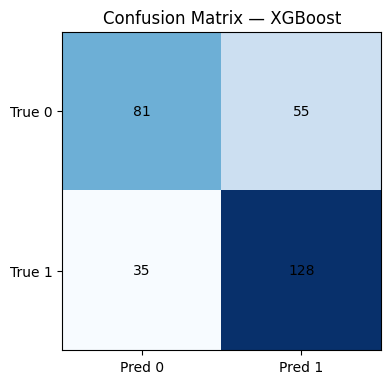

In [41]:
print("Confusion matrix (rows = true, cols = predicted), order = [0, 1]:")
cm = confusion_matrix(y, best_pred)
print(cm)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
ax.set_title(f"Confusion Matrix — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()


In [42]:
# Repeated CV for a robust estimate (base models only — ensembles are evaluated via the
# single-pass OOF above since StackingClassifier/VotingClassifier CV is already expensive).
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
repeated_summary = {}
for name, pipe in MODELS.items():
    scores = cross_val_score(pipe, X, y, cv=rcv, scoring="f1_macro", n_jobs=-1)
    repeated_summary[name] = (scores.mean(), scores.std())
    print(f"{name:<20} Macro-F1 = {scores.mean():.4f} +/- {scores.std():.4f}")


LogisticRegression   Macro-F1 = 0.6497 +/- 0.0466
RandomForest         Macro-F1 = 0.6555 +/- 0.0648
XGBoost              Macro-F1 = 0.6762 +/- 0.0304
LightGBM             Macro-F1 = 0.6576 +/- 0.0471


# Error Analysis

Split performance by context availability, and inspect false positives / false
negatives to see which feature types need improvement.

In [43]:
df["_best_pred"] = best_pred
df["_best_proba"] = best_proba

for has_ctx, group in df.groupby("has_context"):
    macro_f1 = f1_score(group["label"], group["_best_pred"], average="macro")
    print(f"has_context={has_ctx}: Macro-F1 = {macro_f1:.4f}  (n={len(group)})")


has_context=False: Macro-F1 = 0.6095  (n=169)
has_context=True: Macro-F1 = 0.7862  (n=130)


In [44]:
false_positives = df[(df["label"] == 0) & (df["_best_pred"] == 1)]   # predicted faithful, actually hallucinated
false_negatives = df[(df["label"] == 1) & (df["_best_pred"] == 0)]   # predicted hallucinated, actually faithful

print(f"False positives (missed hallucinations): {len(false_positives)}")
print(f"False negatives (faithful flagged wrongly): {len(false_negatives)}")

print("\nFeature averages — false positives vs. rest:")
diagnostic_cols = ["cos_context_response_filled", "nli_entailment_filled", "cultural_default_flag",
                    "entity_support_ratio", "cross_lingual_disagreement_filled"]
print(pd.DataFrame({
    "false_positives_mean": false_positives[diagnostic_cols].mean(),
    "overall_mean": df[diagnostic_cols].mean(),
}))


False positives (missed hallucinations): 55
False negatives (faithful flagged wrongly): 35

Feature averages — false positives vs. rest:
                                   false_positives_mean  overall_mean
cos_context_response_filled                    0.804578      0.808970
nli_entailment_filled                          0.701907      0.714261
cultural_default_flag                          0.000000      0.000000
entity_support_ratio                           0.681818      0.747492
cross_lingual_disagreement_filled              0.140681      0.148856


In [45]:
pd.set_option("display.max_colwidth", 100)
print("Sample false positives (model said faithful, truly hallucinated):")
display(false_positives[["prompt_bn", "response_bn", "context", "_best_proba"]].head(5))

print("\nSample false negatives (model said hallucinated, truly faithful):")
display(false_negatives[["prompt_bn", "response_bn", "context", "_best_proba"]].head(5))


Sample false positives (model said faithful, truly hallucinated):


,prompt_bn,response_bn,context,_best_proba
2,‘কাঁঠালপাড়া’য় জন্মগ্রহণ করেন কোন লেখক?,শরৎচন্দ্র চট্টোপাধ্যায়,,0.770653
3,তারেক মাসুদ পরিচালিত সর্বশেষ বাংলা চলচ্চিত্রটি কত সালে বাংলাদেশে মুক্তি পায় ?,রানওয়ে,তারেক মাসুদ পরিচালিত প্রথম স্বল্পদৈর্ঘ্য চলচ্চিত্র সোনার বেড়ি (১৯৮৫) এবং সর্বশেষ পূর্ণদৈর্ঘ্য চ...,0.988608
5,দুই অঙ্কবিশিষ্ট একটি সংখ্যার এককের অঙ্ক দশকের অঙ্ক অপেক্ষা ৩ বেশি। সংখ্যাটি এর অঙ্কদ্বয়ের সমষ্টি...,৪৭,,0.690102
14,ডক্টর ইউনূসের নেতৃত্বে অন্তর্বর্তীকালীন সরকার কবে শপথ গ্রহণ করে?,"৫ অগাস্ট, ২০২৪",,0.926851
18,প্রথম সুলাইমানের পর কে উসমানীয় সাম্রাজ্যের সম্রাট হন ?,প্রথম সুলাইমানের পর উসমানীয় সাম্রাজ্যের সম্রাট হন তৃতীয় মুরাদ।,"১৫৬৬ সালের ৫ই সেপ্টেম্বর, সুলাইমান, তিনি তখন হাঙ্গেরি অভিযানের নেতৃত্ব দেয়ার উদ্দেশ্যে কনস্টান্...",0.864495



Sample false negatives (model said hallucinated, truly faithful):


,prompt_bn,response_bn,context,_best_proba
19,জে. কে. রাউলিং রচিত হ্যারি পটার উপন্যাসের প্রথম খন্ডের নাম কী ?,হ্যারি পটার অ্যান্ড দ্য ফিলোসফার্স স্টোন,১৯৯৭ সালে হ্যারি পটার অ্যান্ড দ্য ফিলোসফার্স স্টোন (আমেরিকাতে হ্যারি পটার অ্যান্ড সরসারার্স স্টো...,0.017872
25,পদ্মা নদীর দৈর্ঘ্য বাংলাদেশে কত কিলোমিটার?,৩৪১ কিলোমিটার,,0.042929
28,আখতার হামিদ খানের স্ত্রীর নাম কী ?,মোছাঃ রশীদা হামিদ,দাম্পত্য জীবনে আখতার হামিদ খান স্ত্রী মোছাঃ রশীদা হামিদের সাথে সংসারধর্ম পালন করছেন। রশীদা হামিদ...,0.263108
63,মবিডিক কে লিখেছেন?,হারম্যান মেলভিল,,0.033511
69,কোনো স্থানে মাধ্যাকর্ষণজনিত ত্বরণ ৯ গুণ বাড়লে সেখানে একটি সরল দোলকের দোলনকাল কতগুণ বাড়বে বা কমবে?,৩ গুণ কমবে,,0.059068


# Threshold Optimization

Sweep the decision threshold on the best approach's OOF probabilities and pick the one
that maximizes Macro-F1 (the competition metric) instead of assuming 0.50.

Default threshold (0.50) Macro-F1 : 0.6914
Best threshold (0.61) Macro-F1  : 0.6989
Improvement                        : +0.0075


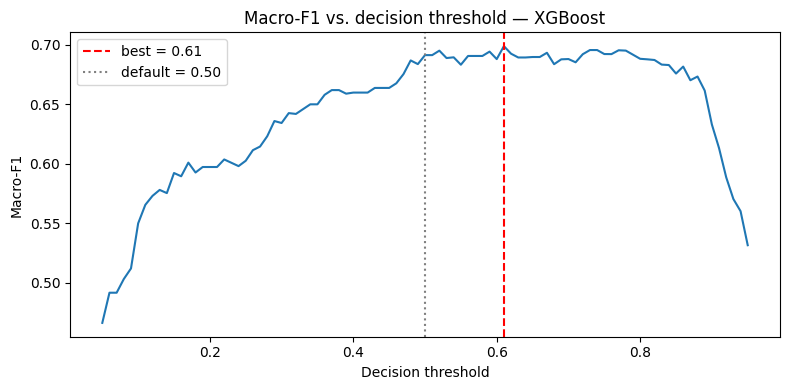

  XGBoost @ tuned threshold (0.61)
  Accuracy    : 0.7023
  Macro-F1    : 0.6989  <- primary metric
  Precision(1): 0.7202
  Recall(1)   : 0.7423
  AUC-ROC     : 0.7470

                  precision    recall  f1-score   support

hallucinated (0)       0.68      0.65      0.67       136
    faithful (1)       0.72      0.74      0.73       163

        accuracy                           0.70       299
       macro avg       0.70      0.70      0.70       299
    weighted avg       0.70      0.70      0.70       299



In [46]:
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_scores = [f1_score(y, (best_proba >= t).astype(int), average="macro") for t in thresholds]

best_idx = np.argmax(threshold_scores)
BEST_THRESHOLD = thresholds[best_idx]
best_threshold_score = threshold_scores[best_idx]
default_score = f1_score(y, (best_proba >= 0.5).astype(int), average="macro")

print(f"Default threshold (0.50) Macro-F1 : {default_score:.4f}")
print(f"Best threshold ({BEST_THRESHOLD:.2f}) Macro-F1  : {best_threshold_score:.4f}")
print(f"Improvement                        : {best_threshold_score - default_score:+.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, threshold_scores)
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"best = {BEST_THRESHOLD:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="default = 0.50")
plt.xlabel("Decision threshold")
plt.ylabel("Macro-F1")
plt.legend()
plt.title(f"Macro-F1 vs. decision threshold — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

tuned_pred = (best_proba >= BEST_THRESHOLD).astype(int)
report(y, tuned_pred, best_proba, name=f"{BEST_MODEL_NAME} @ tuned threshold ({BEST_THRESHOLD:.2f})")


# Test Inference & Submission

Regenerate every feature block on `test.csv`, fit the chosen model(s) on the **full**
labeled sample, and write `submission.csv` in `id,label` format.

> This cell defines `build_features(frame)` so the exact same feature logic used for
> training is replayed on the test set — no duplicated/out-of-sync code paths.

In [47]:
def build_features(frame, is_train_context_median=None):
       
    frame = frame.copy()
    for col in ["prompt_bn", "response_bn"]:
        frame[col] = frame[col].astype(str)
    frame["context"] = frame["context"].apply(clean_context) if "context" in frame.columns else ""
    frame["has_context"] = frame["context"].astype(str).str.len() > 0
    frame["has_context_int"] = frame["has_context"].astype(int)

    for col in ["prompt_bn", "response_bn", "context"]:
        frame[f"{col}_clean"] = frame[col].apply(normalize_text)
        frame[f"{col}_len"] = frame[col].str.len()

    # Feature 2/3 — embeddings + cosine similarity
    ep = e5_encode(frame["prompt_bn_clean"].tolist())
    er = e5_encode(frame["response_bn_clean"].tolist())
    ec = e5_encode(frame["context_clean"].tolist())
    frame["cos_prompt_response"] = row_cosine(ep, er)
    frame["cos_context_response"] = row_cosine(ec, er)
    frame.loc[~frame["has_context"], "cos_context_response"] = np.nan
    frame["cos_context_response_filled"] = frame["cos_context_response"].fillna(df["cos_context_response"].median())

    # Feature 4 — NLI
    ctx_rows = frame[frame["has_context"]]
    scores = [nli_entailment_score(r.context_clean, r.response_bn_clean)
              for r in tqdm(ctx_rows.itertuples(), total=len(ctx_rows), desc="NLI (test)")]
    frame["nli_entailment"] = np.nan
    frame.loc[ctx_rows.index, "nli_entailment"] = scores
    frame["nli_entailment_filled"] = frame["nli_entailment"].fillna(NLI_FILL_VALUE)

    # Feature 5 — factcheck (no-context rows only)
    no_ctx_rows = frame[~frame["has_context"]]
    fc = [factcheck_score(r.prompt_bn_clean, r.response_bn_clean)
          for r in tqdm(no_ctx_rows.itertuples(), total=len(no_ctx_rows), desc="Factcheck (test)")]
    frame["factcheck_score"] = np.nan
    frame.loc[no_ctx_rows.index, "factcheck_score"] = fc
    frame["factcheck_score_filled"] = frame["factcheck_score"].fillna(frame["nli_entailment_filled"])

    # Feature 6 — cross-lingual disagreement
    p_en, r_en, c_en = {}, {}, {}
    for idx, row in frame.iterrows():
        p_en[idx] = translate_bn_to_en(row["prompt_bn_clean"])
        r_en[idx] = translate_bn_to_en(row["response_bn_clean"])
        c_en[idx] = translate_bn_to_en(row["context_clean"]) if row["has_context"] else ""
    frame["prompt_en"] = frame.index.map(p_en)
    frame["response_en"] = frame.index.map(r_en)
    frame["context_en"] = frame.index.map(c_en)
    en_ctx_rows = frame[frame["has_context"]]
    en_scores = [english_entailment(r.context_en, r.response_en)
                 for r in tqdm(en_ctx_rows.itertuples(), total=len(en_ctx_rows), desc="EN NLI (test)")]
    frame["nli_entailment_en"] = np.nan
    frame.loc[en_ctx_rows.index, "nli_entailment_en"] = en_scores
    frame["cross_lingual_disagreement"] = (frame["nli_entailment"] - frame["nli_entailment_en"]).abs()
    frame["cross_lingual_disagreement_filled"] = frame["cross_lingual_disagreement"].fillna(0.0)

    # Feature 7 — entity verification
    ent_feats = frame.apply(entity_consistency_row, axis=1)
    frame = pd.concat([frame, ent_feats], axis=1)

    # Feature 8 — numeric consistency
    num_feats = frame.apply(numeric_consistency_row, axis=1)
    frame = pd.concat([frame, num_feats], axis=1)

    # Feature 9 — cultural default
    frame["cultural_default_flag"] = frame.apply(cultural_default_flag, axis=1)

    # Feature 11 — lexical overlap
    frame["overlap_prompt_response"] = frame.apply(
        lambda r: overlap_ratio(r["prompt_bn_clean"], r["response_bn_clean"]), axis=1)
    frame["overlap_context_response"] = frame.apply(
        lambda r: overlap_ratio(r["context_clean"], r["response_bn_clean"]) if r["has_context"] else np.nan, axis=1)
    frame["overlap_context_response_filled"] = frame["overlap_context_response"].fillna(
        df["overlap_context_response"].median())

    # Feature 12 — length ratios
    frame["response_prompt_len_ratio"] = frame["response_bn_len"] / frame["prompt_bn_len"].replace(0, 1)
    frame["response_context_len_ratio"] = np.where(
        frame["has_context"], frame["response_bn_len"] / frame["context_len"].replace(0, 1), np.nan)
    frame["response_context_len_ratio_filled"] = frame["response_context_len_ratio"].fillna(
        df["response_context_len_ratio"].median())

    # Feature 13 — jaccard
    frame["jaccard_prompt_response"] = frame.apply(
        lambda r: jaccard(r["prompt_bn_clean"], r["response_bn_clean"]), axis=1)
    frame["jaccard_context_response"] = frame.apply(
        lambda r: jaccard(r["context_clean"], r["response_bn_clean"]) if r["has_context"] else np.nan, axis=1)
    frame["jaccard_context_response_filled"] = frame["jaccard_context_response"].fillna(
        df["jaccard_context_response"].median())

    return frame

print("build_features() defined.")


build_features() defined.


In [48]:
if test_df is not None:
    test_df = build_features(test_df)

    # Refit the best model family on the FULL labeled sample, then predict on test.
    final_pipe = MODELS[BEST_MODEL_NAME] if BEST_MODEL_NAME in MODELS else voting_clf
    final_pipe.fit(X, y)

    test_proba = final_pipe.predict_proba(test_df)[:, 1]
    test_pred = (test_proba >= BEST_THRESHOLD).astype(int)

    submission = pd.DataFrame({
        "id": test_df["id"] if "id" in test_df.columns else range(len(test_df)),
        "label": test_pred,
    })
    submission.to_csv("submission.csv", index=False)
    print(f"Wrote submission.csv with {len(submission)} rows.")
    display(submission.head())
else:
    print(f'No test file found at "{TEST_PATH}" yet — run this cell again once it is available.')


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

NLI (test):   0%|          | 0/1361 [00:00<?, ?it/s]

Factcheck (test):   0%|          | 0/1155 [00:00<?, ?it/s]

EN NLI (test):   0%|          | 0/1361 [00:00<?, ?it/s]

Wrote submission.csv with 2516 rows.


,id,label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1


# Next Steps / Ideas to Push Further

- Expand the **cultural-default gazetteer** as you read more of the sample split — every
  C1 mistake you spot by eye is a new rule.
- Subsample / cache translations (Feature 6) more aggressively if the NLLB pass is the
  runtime bottleneck; consider batching `translate_bn_to_en` instead of row-by-row.
- Try a dedicated Bengali NER model instead of the general multilingual one in Feature 7,
  if available and open-weight.
- Fine-tune a Bengali encoder (e.g. `csebuetnlp/banglabert`) end-to-end as an additional
  base learner for the ensemble, using the same `prompt + context + response` input
  format used in earlier experiments.
- Per-band calibration: bucket rows by `has_context` × `cultural_default_flag` and tune
  thresholds separately per bucket instead of one global threshold.
- Error-analyze by task type (trivia / QA / proverb interpretation) if that metadata is
  available in a later data drop.
- Retrieval grounding for closed-book (`has_context=False`) rows: retrieve a supporting
  passage before fact-checking, rather than relying solely on the LLM's parametric
  knowledge.
